<center>
<img src = "https://www.udd.cl/dircom/web/udd/facultades/Ingenieria.png" width = "500px">

# **Temas Interdisciplinarios**
## Primer Avance
</center>

**Nombres:** Luis-Felipe Cáceres y Nicolas Bravo
**Fecha de entrega:** 6/04/2026

En este avance se veran el desarollo de las siguientes preguntas:

* **¿Las ciudades con mayor contaminación presentan tasas más altas de enfermedades respiratorias?**

* **¿Existe una relación entre la desigualdad socioeconomíca y el rendimiento escolar?**

* **¿La urbanización se asocia con niveles más altos de contaminación?**

* **¿El nivel de ingreso predice el acceso a la educación superior?**

* **¿Las ciudades mas grandes tendran mayor indice de pobreza?**


El desarrollo de los dataset se haran por separados, cada pregunta tendra su propio desarollo


<br>

---

<center>

# **Librerías**
</center>

In [ ]:
import pandas as pd        # pandas: librería principal para manipular tablas de datos (DataFrames)
import numpy as np         # numpy: librería para operaciones matemáticas y manejo de arreglos numéricos
import matplotlib.pyplot as plt  # matplotlib.pyplot: módulo para crear gráficos y visualizaciones
import seaborn as sns      # seaborn: librería de visualización de alto nivel, construida sobre matplotlib

<br>

---
<center>

# **Pregunta 1**
# **¿Las ciudades con mayor contaminación presentan tasas más altas de enfermedades respiratorias?**

</center>

### Datasets:

In [ ]:
path = "basesDeDatos/pregunta_1/"
urgencias = pd.read_parquet(path + 'at_urg_respiratorio_semanal.parquet')
contaminacion = pd.read_excel(path + 'efd-ckan-2023.xlsx')

<center>

# **Limpieza de datos**
</center>

## **Valores ausentes**


In [ ]:
print("DATAFRAME DE URGENCIAS RESPIRATORIAS:")
display(urgencias.isnull().sum())
print("================================================================")
print("DATAFRAME DE CONTAMINACIÓN:")
display(contaminacion.isnull().sum())

Se puede observar que el Dataframe de urgencias respiratorias tiene 18576 datos nulos, los datos nulos seran borrados ya que no sirven debido que justo en la columna de nulos estan los datos geograficos

In [ ]:
urgencias = urgencias.dropna()

Ademas en urgencias, nos quedaremos con un groupby de ComunaGlosa y su total de emergencias, ya que para nuestro caso de estudio no nos interesa ninguna otra variable.

Para contaminacion nos quedaremos con la cantidad total de toneladas emitadas por comuna, ya que no nos sirve ninguna de las otra variables para este estudio

In [ ]:
urgencias = urgencias.groupby('ComunaGlosa').size().to_frame('total_emergencias')
urgencias.index.name = 'comuna'

contaminacion = contaminacion.groupby('comuna')['cantidad_toneladas'].sum().to_frame('cantidad_total_toneladas')


## **Outliers**

In [ ]:
IQRUrgecnias = urgencias.quantile(0.75) - urgencias.quantile(0.25)
IQRcontaminacion = contaminacion.quantile(0.75) - contaminacion.quantile(0.25)
limite_superior_urgencias = urgencias.quantile(0.75) + 1.5 * IQRUrgecnias
limite_superior_contaminacion = contaminacion.quantile(0.75) + 1.5 * IQRcontaminacion
limite_inferior_urgencias = urgencias.quantile(0.25) - 1.5 * IQRUrgecnias
limite_inferior_contaminacion = contaminacion.quantile(0.25) - 1.5 * IQRcontaminacion

outliers_urgencias = urgencias[(urgencias['total_emergencias'] > limite_superior_urgencias['total_emergencias']) | (urgencias['total_emergencias'] < limite_inferior_urgencias['total_emergencias'])]
outliers_contaminacion = contaminacion[(contaminacion['cantidad_total_toneladas'] > limite_superior_contaminacion['cantidad_total_toneladas']) | (contaminacion['cantidad_total_toneladas'] < limite_inferior_contaminacion['cantidad_total_toneladas'])]
print("Outliers en urgencias respiratorias:")
display(outliers_urgencias.shape[0])
print("Outliers en contaminación:")
display(outliers_contaminacion.shape[0]) 

<center>

# **Estadísticas descriptivas**

</center>


In [ ]:
print("URGENCIAS:")
display(urgencias.describe())
print("================================================================")
print("CONTAMINACIÓN:")
display(contaminacion.describe())

<center>

# **Visualizaciones**

</center>

para esto vammos a unir los dos dataframes

In [ ]:
union =pd.merge(contaminacion, urgencias, left_on='comuna', right_on='comuna', how='inner')

# **Scatter**
Esto se utliza para poder ver la relacion entre las dos variables

In [ ]:
outlier = union['cantidad_total_toneladas'].idxmax()
union_plot = union.drop(index=outlier)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    union_plot['cantidad_total_toneladas'],
    union_plot['total_emergencias'],
    color='steelblue', alpha=0.7, edgecolors='white', s=80, zorder=3
)

# Línea de tendencia
m, b = np.polyfit(union_plot['cantidad_total_toneladas'], union_plot['total_emergencias'], 1)
x_line = np.linspace(union_plot['cantidad_total_toneladas'].min(), union_plot['cantidad_total_toneladas'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label=f'Tendencia (pendiente={m:.2f})')



ax.set_xlabel('Contaminación total (toneladas)', fontsize=12)
ax.set_ylabel('Total de emergencias respiratorias', fontsize=12)
ax.set_title('¿A mayor contaminación, más emergencias respiratorias?\n(por comuna, 2023)', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr = union_plot['cantidad_total_toneladas'].corr(union_plot['total_emergencias'])
print(f"Correlación de Pearson: {corr:.3f}")

# **Bar**
Con esto podremos ver que ciudades estan en el top 10 o los ultimos 10

In [ ]:

# Colores y estilo profesional
COLOR_ALTO = '#C0392B'
COLOR_BAJO = '#2980B9'

top10_contam     = union_plot.sort_values('cantidad_total_toneladas', ascending=False).head(10)
bottom10_contam  = union_plot.sort_values('cantidad_total_toneladas', ascending=True).head(10)
top10_emerg      = union_plot.sort_values('total_emergencias', ascending=False).head(10)
bottom10_emerg   = union_plot.sort_values('total_emergencias', ascending=True).head(10)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis de Contaminación y Emergencias Respiratorias por Comuna (2023)',
             fontsize=16, fontweight='bold', y=1.01)

datasets = [
    (axes[0, 0], top10_contam,    'cantidad_total_toneladas', COLOR_ALTO,
     'Top 10 comunas con MAYOR contaminación', 'Toneladas emitidas'),
    (axes[0, 1], bottom10_contam, 'cantidad_total_toneladas', COLOR_BAJO,
     'Top 10 comunas con MENOR contaminación', 'Toneladas emitidas'),
    (axes[1, 0], top10_emerg,     'total_emergencias',        COLOR_ALTO,
     'Top 10 comunas con MAYOR emergencias respiratorias', 'N° de emergencias'),
    (axes[1, 1], bottom10_emerg,  'total_emergencias',        COLOR_BAJO,
     'Top 10 comunas con MENOR emergencias respiratorias', 'N° de emergencias'),
]

for ax, data, col, color, title, ylabel in datasets:
    bars = ax.bar(data.index, data[col], color=color, alpha=0.85, edgecolor='white', linewidth=0.8)

    # Etiquetas de valor encima de cada barra
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                f'{h:,.0f}', ha='center', va='bottom', fontsize=8, color='#333333')

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel('Comuna', fontsize=10)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index, rotation=40, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('barras_contaminacion_emergencias.png', dpi=150, bbox_inches='tight')
plt.show()


## **Histogramas y Boxplots**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(urgencias['total_emergencias'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Distribución de Emergencias Respiratorias por Comuna', fontsize=11)
axes[0, 0].set_xlabel('Total emergencias')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(urgencias['total_emergencias'].mean(), color='tomato', linewidth=2,
                   label=f"Media: {urgencias['total_emergencias'].mean():.0f}")
axes[0, 0].legend()
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

axes[0, 1].hist(contaminacion['cantidad_total_toneladas'], bins=30, color='#C0392B', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Distribución de Emisiones Contaminantes por Comuna', fontsize=11)
axes[0, 1].set_xlabel('Toneladas emitidas')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)

axes[1, 0].boxplot(urgencias['total_emergencias'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1, 0].set_title('Boxplot: Emergencias Respiratorias por Comuna', fontsize=11)
axes[1, 0].set_ylabel('Total emergencias')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1, 1].boxplot(contaminacion['cantidad_total_toneladas'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#C0392B', alpha=0.7))
axes[1, 1].set_title('Boxplot: Emisiones Contaminantes por Comuna', fontsize=11)
axes[1, 1].set_ylabel('Toneladas emitidas')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histogramas_boxplots_p1.png', dpi=150, bbox_inches='tight')
plt.show()



<center>

# **Estimación estadística**

</center>

### Parámetros de interés

Se estiman los siguientes parámetros para analizar la relación entre contaminación y enfermedades respiratorias:

- **Media y mediana** de emergencias respiratorias según nivel de contaminación (alto/bajo)
- **Desviación estándar** como medida de dispersión en cada grupo
- **Intervalo de confianza al 95%** para la media de emergencias por grupo (distribución t)
- **Prueba t de Student** para contrastar si las diferencias entre grupos son significativas

In [ ]:
import scipy.stats as stats

# Dividir comunas en nivel alto/bajo según la mediana de contaminación
mediana_cont1 = union['cantidad_total_toneladas'].median()
union['nivel_contaminacion'] = pd.cut(
    union['cantidad_total_toneladas'],
    bins=[union['cantidad_total_toneladas'].min() - 1, mediana_cont1, union['cantidad_total_toneladas'].max()],
    labels=['Contaminación baja', 'Contaminación alta']
)

estimadores1 = []
for nivel, grupo in union.groupby('nivel_contaminacion')['total_emergencias']:
    n = len(grupo)
    media = grupo.mean()
    mediana = grupo.median()
    std = grupo.std()
    se = std / np.sqrt(n)
    ic_low, ic_high = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    estimadores1.append({
        'Nivel contaminación': str(nivel),
        'N': n,
        'Media emergencias': round(media, 1),
        'Mediana': round(mediana, 1),
        'Desv. Std': round(std, 1),
        'IC 95% inf': round(ic_low, 1),
        'IC 95% sup': round(ic_high, 1),
    })

tabla_est1 = pd.DataFrame(estimadores1).set_index('Nivel contaminación')
print("Estimadores de emergencias respiratorias por nivel de contaminación:")
display(tabla_est1)


In [ ]:
# Prueba t de Student: ¿hay diferencia significativa entre grupos?
grupo_alto1 = union[union['nivel_contaminacion'] == 'Contaminación alta']['total_emergencias']
grupo_bajo1 = union[union['nivel_contaminacion'] == 'Contaminación baja']['total_emergencias']
t_stat1, p_valor1 = stats.ttest_ind(grupo_alto1, grupo_bajo1)

print("Prueba t de Student (alto vs bajo contaminación):")
print(f"  t = {t_stat1:.3f}")
print(f"  p-valor = {p_valor1:.4f}")
if p_valor1 < 0.05:
    print("  → Diferencia estadísticamente significativa (α = 0.05)")
else:
    print("  → No hay diferencia estadísticamente significativa (α = 0.05)")


In [ ]:
# Tabla resumen general - Pregunta 1
corr1 = union_plot['cantidad_total_toneladas'].corr(union_plot['total_emergencias'])

resumen1 = pd.DataFrame({
    'Estimador': [
        'Media emergencias respiratorias por comuna',
        'Mediana emergencias respiratorias',
        'Media emisiones contaminantes (ton)',
        'Mediana emisiones contaminantes (ton)',
        'Correlación Pearson (emisiones vs emergencias)',
        '% comunas con contaminación alta',
    ],
    'Valor': [
        round(union['total_emergencias'].mean(), 1),
        round(union['total_emergencias'].median(), 1),
        f"{union['cantidad_total_toneladas'].mean():,.0f}",
        f"{union['cantidad_total_toneladas'].median():,.0f}",
        round(corr1, 3),
        f"{(union['nivel_contaminacion'] == 'Contaminación alta').mean() * 100:.1f}%",
    ]
})
print("=== TABLA RESUMEN — PREGUNTA 1 ===")
display(resumen1.set_index('Estimador'))


<center>

# **Identificación**
</center>

Se puede ver claramente como las dos variables no tienen una correlacion entre ellas, por lo tanto no es correcto decir que a mayor contaminacion, mas emegergencias respiratorias

<br>

---
<center>

# **Pregunta 2**
# **¿Existe una relación entre la desigualdad socioeconómica y el rendimiento escolar?**

</center>

### Datasets:

In [107]:
path2 = "basesDeDatos/pregunta_2/"
simce2 = pd.read_csv(path2 + "simce2m2024_rbd_preliminar.csv", encoding="latin1", sep=";")
idps2  = pd.read_csv(path2 + "idps2M2024_rbd_preliminar.csv",  encoding="latin1", sep=";")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

<center>

# **Limpieza de datos**
</center>

## **Valores ausentes**

In [108]:
print("DATAFRAME SIMCE:")
display(simce2.isnull().sum())
print("================================================================")
print("DATAFRAME IDPS:")
display(idps2.isnull().sum())

DATAFRAME SIMCE:


rbd                           0
dvrbd                         0
nom_rbd                       0
cod_reg_rbd                   0
nom_reg_rbd                   0
cod_pro_rbd                   0
nom_pro_rbd                   0
cod_com_rbd                   0
nom_com_rbd                   0
cod_deprov_rbd                0
nom_deprov_rbd                0
cod_depe1                     0
cod_depe2                     0
cod_grupo                     5
cod_rural_rbd                 0
nalu_lect2m_rbd               0
nalu_mate2m_rbd               0
prom_lect2m_rbd               7
prom_mate2m_rbd               6
dif_lect2m_rbd              184
dif_mate2m_rbd              212
difgru_lect2m_rbd            93
difgru_mate2m_rbd           117
sigdif_lect2m_rbd           184
sigdif_mate2m_rbd           212
siggru_lect2m_rbd            93
siggru_mate2m_rbd           117
marca_lect2m_rbd           2923
marca_mate2m_rbd           2903
marcadif_lect2m_rbd        2821
marcadif_mate2m_rbd        2793
palu_eda

DATAFRAME IDPS:


agno                 0
rbd                  0
ind                  0
prom                45
dif               1115
sigdif            1115
difgru             105
sigdifgru          105
nom_rbd              0
cod_reg_rbd          0
nom_reg_rbd          0
cod_pro_rbd          0
nom_pro_rbd          0
cod_com_rbd          0
nom_com_rbd          0
nom_deprov_rbd       0
cod_depe2            0
cod_grupo           20
cod_rural_rbd        0
codigo_bdd           0
fecha_bbdd           0
grado                0
dtype: int64

Se utilizan dos datasets del año 2024 a nivel de establecimiento (RBD): SIMCE con puntajes de lectura y matemática, e IDPS con indicadores de desarrollo personal y social. Se aplican traducciones a las categorías, se transforma IDPS a formato ancho y se unen ambas bases, conservando solo las variables relevantes.

In [109]:
# Diccionarios de traducción
gse_map   = {1: "Bajo", 2: "Medio bajo", 3: "Medio", 4: "Medio alto", 5: "Alto"}
dep_map   = {1: "Municipal", 2: "Particular subvencionado", 3: "Particular pagado", 4: "SLEP"}
rural_map = {1: "Urbano", 2: "Rural"}

# Aplicar traducciones a SIMCE
simce2["gse"]         = simce2["cod_grupo"].map(gse_map)
simce2["dependencia"] = simce2["cod_depe2"].map(dep_map)
simce2["ruralidad"]   = simce2["cod_rural_rbd"].map(rural_map)

# Transformar IDPS a formato ancho
idps_wide2 = idps2.pivot_table(
    index=["rbd", "nom_rbd", "cod_reg_rbd", "nom_reg_rbd", "cod_pro_rbd", "nom_pro_rbd",
           "cod_com_rbd", "nom_com_rbd", "nom_deprov_rbd", "cod_depe2", "cod_grupo",
           "cod_rural_rbd", "agno", "grado"],
    columns="ind", values="prom", aggfunc="first"
).reset_index()
idps_wide2.columns.name = None

# Unir ambas bases
base2 = simce2.merge(idps_wide2, on=["rbd", "agno", "grado"], how="inner", suffixes=("_simce", "_idps"))

# Seleccionar y renombrar columnas relevantes
base_p2 = base2[[
    "rbd", "nom_rbd_simce", "nom_reg_rbd_simce", "nom_com_rbd_simce",
    "cod_grupo_simce", "cod_depe2_simce", "cod_rural_rbd_simce",
    "prom_lect2m_rbd", "prom_mate2m_rbd", "AM", "CC", "HV", "PF"
]].copy()

base_p2 = base_p2.rename(columns={
    "nom_rbd_simce": "nom_rbd",     "nom_reg_rbd_simce": "region",
    "nom_com_rbd_simce": "comuna",  "cod_grupo_simce": "cod_grupo",
    "cod_depe2_simce": "cod_depe2", "cod_rural_rbd_simce": "cod_rural_rbd"
})

base_p2["gse"]         = base_p2["cod_grupo"].map(gse_map)
base_p2["dependencia"] = base_p2["cod_depe2"].map(dep_map)
base_p2["ruralidad"]   = base_p2["cod_rural_rbd"].map(rural_map)

# Eliminar filas sin GSE o puntajes
base_p2 = base_p2.dropna(subset=["gse", "prom_lect2m_rbd", "prom_mate2m_rbd"])

# Orden lógico de los grupos socioeconómicos
orden_gse = ["Bajo", "Medio bajo", "Medio", "Medio alto", "Alto"]

## **Outliers**

In [110]:
IQR_lect = base_p2["prom_lect2m_rbd"].quantile(0.75) - base_p2["prom_lect2m_rbd"].quantile(0.25)
IQR_mate = base_p2["prom_mate2m_rbd"].quantile(0.75) - base_p2["prom_mate2m_rbd"].quantile(0.25)

limite_sup_lect = base_p2["prom_lect2m_rbd"].quantile(0.75) + 1.5 * IQR_lect
limite_inf_lect = base_p2["prom_lect2m_rbd"].quantile(0.25) - 1.5 * IQR_lect
limite_sup_mate = base_p2["prom_mate2m_rbd"].quantile(0.75) + 1.5 * IQR_mate
limite_inf_mate = base_p2["prom_mate2m_rbd"].quantile(0.25) - 1.5 * IQR_mate

outliers_lect = base_p2[
    (base_p2["prom_lect2m_rbd"] > limite_sup_lect) |
    (base_p2["prom_lect2m_rbd"] < limite_inf_lect)
]
outliers_mate = base_p2[
    (base_p2["prom_mate2m_rbd"] > limite_sup_mate) |
    (base_p2["prom_mate2m_rbd"] < limite_inf_mate)
]

print("Outliers en puntaje de lectura:")
display(outliers_lect.shape[0])
print("Outliers en puntaje de matemática:")
display(outliers_mate.shape[0])

Outliers en puntaje de lectura:


7

Outliers en puntaje de matemática:


44

<center>

# **Estadísticas descriptivas**

</center>

In [111]:
display(base_p2[["prom_lect2m_rbd", "prom_mate2m_rbd", "AM", "CC", "HV", "PF"]].describe().round(2))

,prom_lect2m_rbd,prom_mate2m_rbd,AM,CC,HV,PF
count,2991.00,2991.00,2991.00,2978.00,2991.00,2991.00
mean,250.93,259.73,74.24,75.64,70.19,77.47
std,26.17,40.26,4.17,4.58,5.27,5.04
min,161.00,185.00,59.00,61.00,36.00,59.00
25%,232.00,229.00,72.00,72.00,67.00,74.00
50%,249.00,251.00,74.00,76.00,70.00,77.00
75%,269.00,283.00,77.00,79.00,74.00,81.00
max,329.00,426.00,95.00,95.00,87.00,97.00


<center>

# **Visualizaciones**

</center>

### 7.1 Gráfico de cantidad de establecimientos por GSE

/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3482336280.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.countplot(
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3482336280.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_gse, fontsize=10)


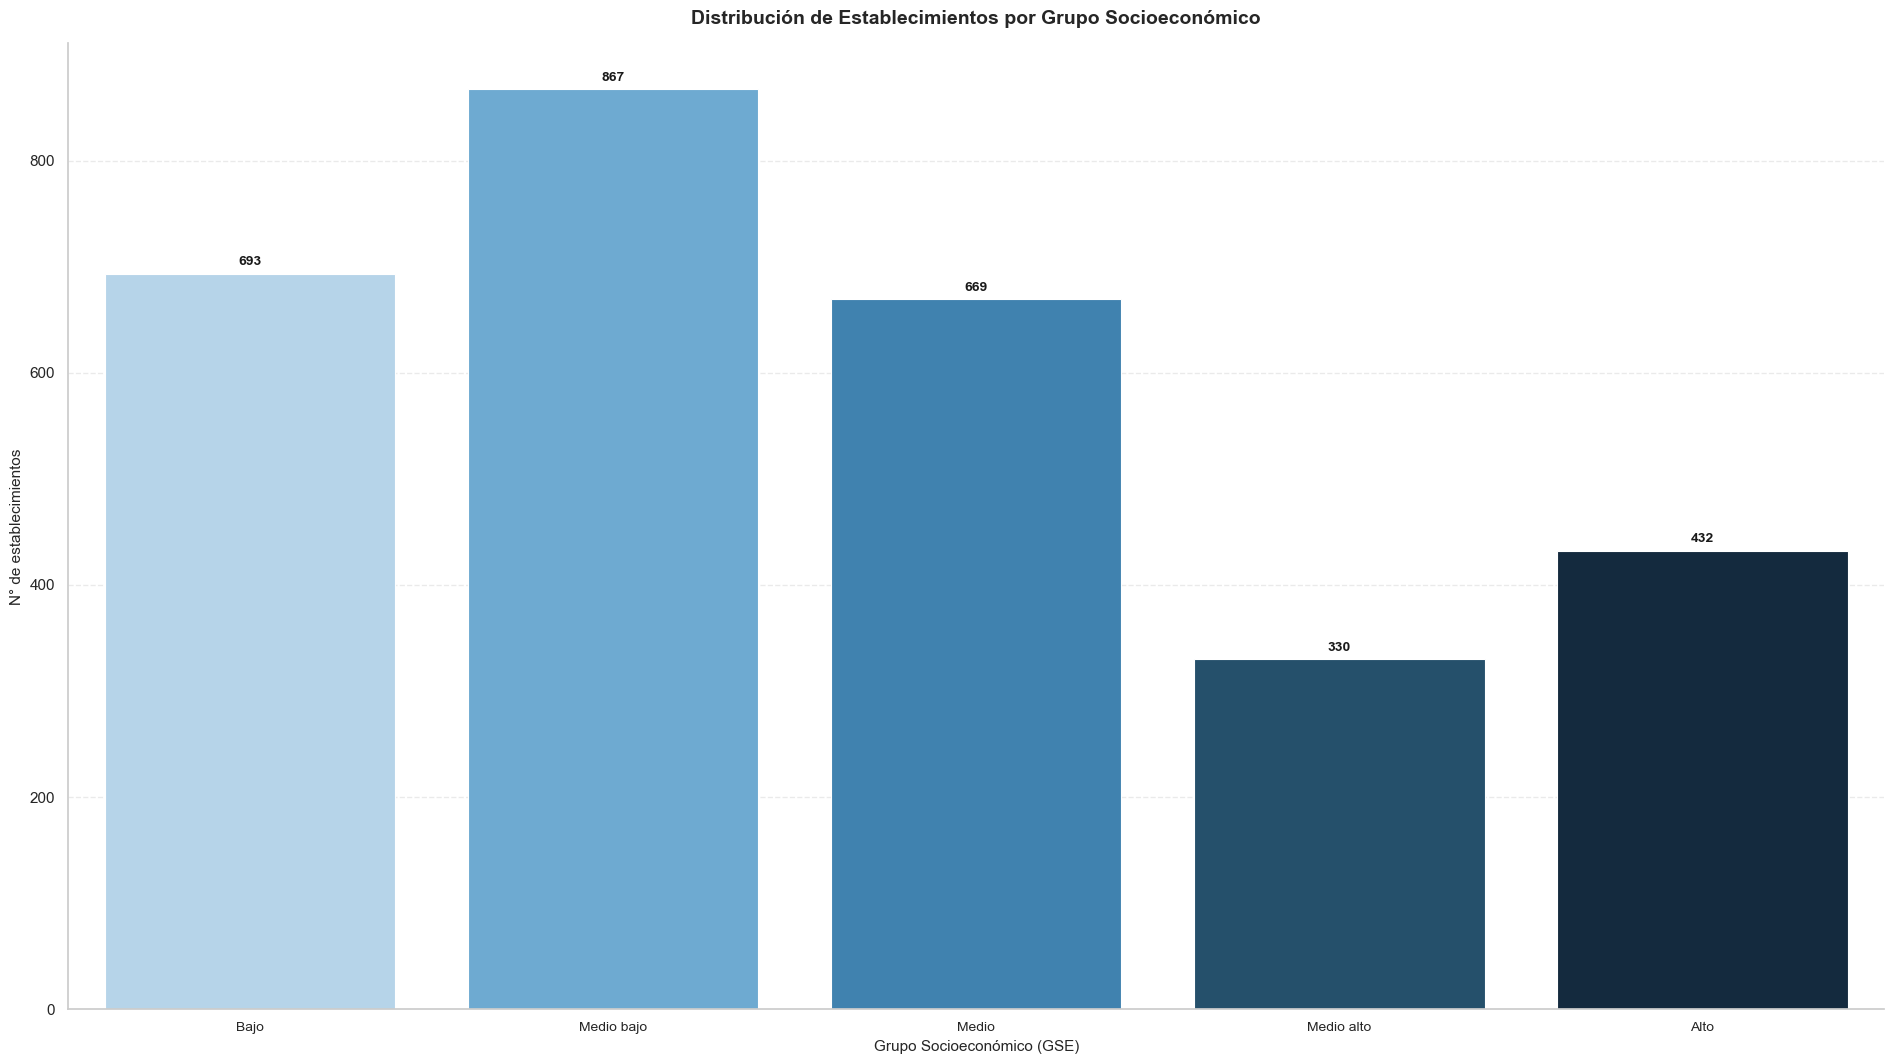

In [126]:
PALETA_GSE = ["#AED6F1", "#5DADE2", "#2E86C1", "#1A5276", "#0D2B45"]

fig, ax = plt.subplots(figsize=(19.1, 10.8))
bars = sns.countplot(
    data=base_p2, x="gse", order=orden_gse,
    palette=PALETA_GSE, edgecolor="white", linewidth=0.8, ax=ax
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a1a1a',
        xytext=(0, 4), textcoords='offset points'
    )

ax.set_title('Distribución de Establecimientos por Grupo Socioeconómico',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Grupo Socioeconómico (GSE)', fontsize=11)
ax.set_ylabel('N° de establecimientos', fontsize=11)
ax.set_xticklabels(orden_gse, fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('p2_countplot_gse.png', dpi=150, bbox_inches='tight')
plt.show()


El gráfico muestra cómo se distribuyen los establecimientos según su grupo socioeconómico (GSE). La mayor cantidad de establecimientos está en el nivel Medio bajo, seguido por Bajo y Medio. Los grupos Medio alto y Alto tienen bastante menos establecimientos.

### 7.2 Boxplot de lectura por GSE

/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3861481773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3861481773.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_gse, fontsize=10)


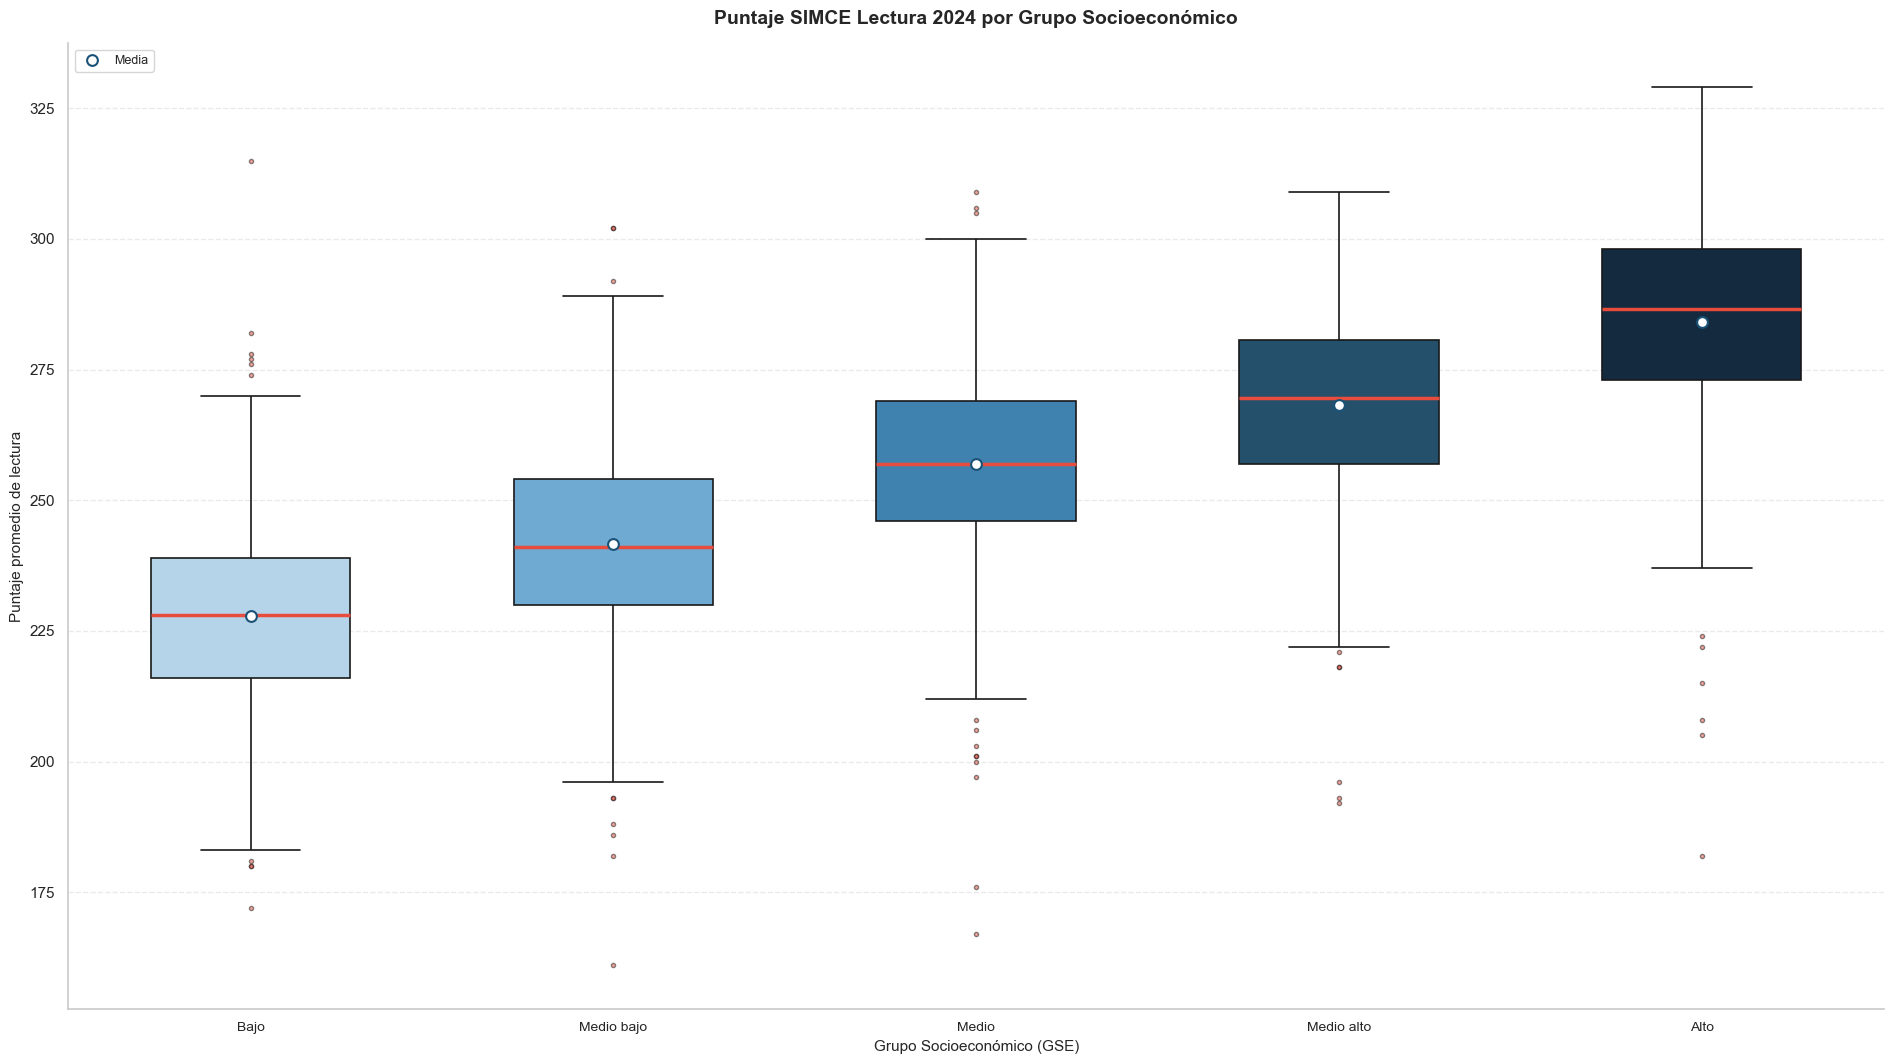

In [125]:
PALETA_GSE = ["#AED6F1", "#5DADE2", "#2E86C1", "#1A5276", "#0D2B45"]

fig, ax = plt.subplots(figsize=(19.1, 10.8))

sns.boxplot(
    data=base_p2, x="gse", y="prom_lect2m_rbd", order=orden_gse,
    palette=PALETA_GSE,
    width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=3, alpha=0.5, linestyle='none'),
    medianprops=dict(color='#E74C3C', linewidth=2.5),
    ax=ax
)

medias = base_p2.groupby('gse')['prom_lect2m_rbd'].mean().reindex(orden_gse)
ax.scatter(range(len(orden_gse)), medias.values, color='white', s=60,
           zorder=5, edgecolors='#1A5276', linewidths=1.5, label='Media')

ax.set_title('Puntaje SIMCE Lectura 2024 por Grupo Socioeconómico',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Grupo Socioeconómico (GSE)', fontsize=11)
ax.set_ylabel('Puntaje promedio de lectura', fontsize=11)
ax.set_xticklabels(orden_gse, fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('p2_boxplot_lectura.png', dpi=150, bbox_inches='tight')
plt.show()


Se observa una relación positiva clara entre el grupo socioeconómico del establecimiento y el puntaje SIMCE en lectura. La diferencia entre los niveles más bajo y más alto alcanza aproximadamente 60 puntos, lo que sugiere una fuerte asociación entre desigualdad socioeconómica y rendimiento académico.

### 7.3 Boxplot de matemáticas por GSE

/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3433410596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/3433410596.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_gse, fontsize=10)


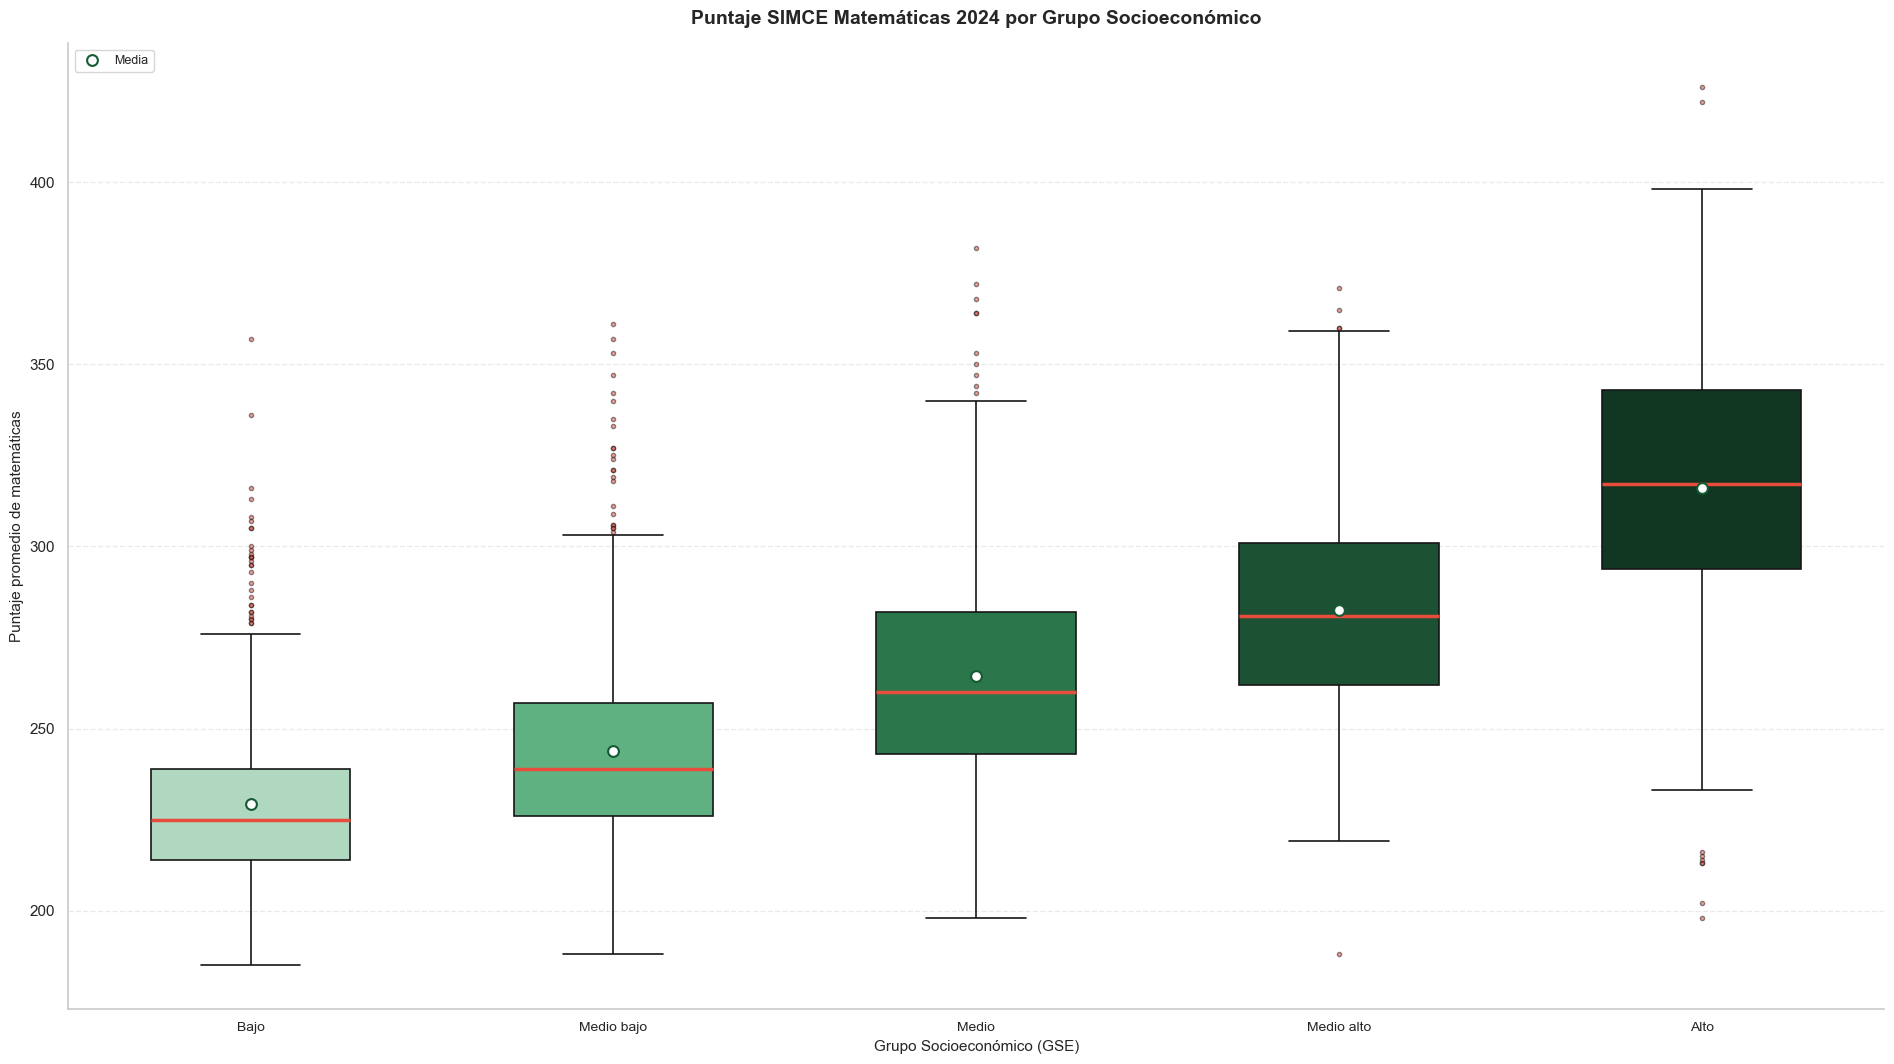

In [127]:
PALETA_GSE_VERDE = ["#A9DFBF", "#52BE80", "#1E8449", "#145A32", "#0B3D21"]

fig, ax = plt.subplots(figsize=(19.1, 10.8))

sns.boxplot(
    data=base_p2, x="gse", y="prom_mate2m_rbd", order=orden_gse,
    palette=PALETA_GSE_VERDE,
    width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=3, alpha=0.5, linestyle='none'),
    medianprops=dict(color='#E74C3C', linewidth=2.5),
    ax=ax
)

medias_m = base_p2.groupby('gse')['prom_mate2m_rbd'].mean().reindex(orden_gse)
ax.scatter(range(len(orden_gse)), medias_m.values, color='white', s=60,
           zorder=5, edgecolors='#145A32', linewidths=1.5, label='Media')

ax.set_title('Puntaje SIMCE Matemáticas 2024 por Grupo Socioeconómico',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Grupo Socioeconómico (GSE)', fontsize=11)
ax.set_ylabel('Puntaje promedio de matemáticas', fontsize=11)
ax.set_xticklabels(orden_gse, fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('p2_boxplot_matematicas.png', dpi=150, bbox_inches='tight')
plt.show()


En matemática la relación es aún más pronunciada que en lectura, con diferencias cercanas a 90 puntos entre los grupos extremos. Esto sugiere que la desigualdad socioeconómica impacta aún más en esta asignatura.

### 7.4 Promedio SIMCE por Grupo

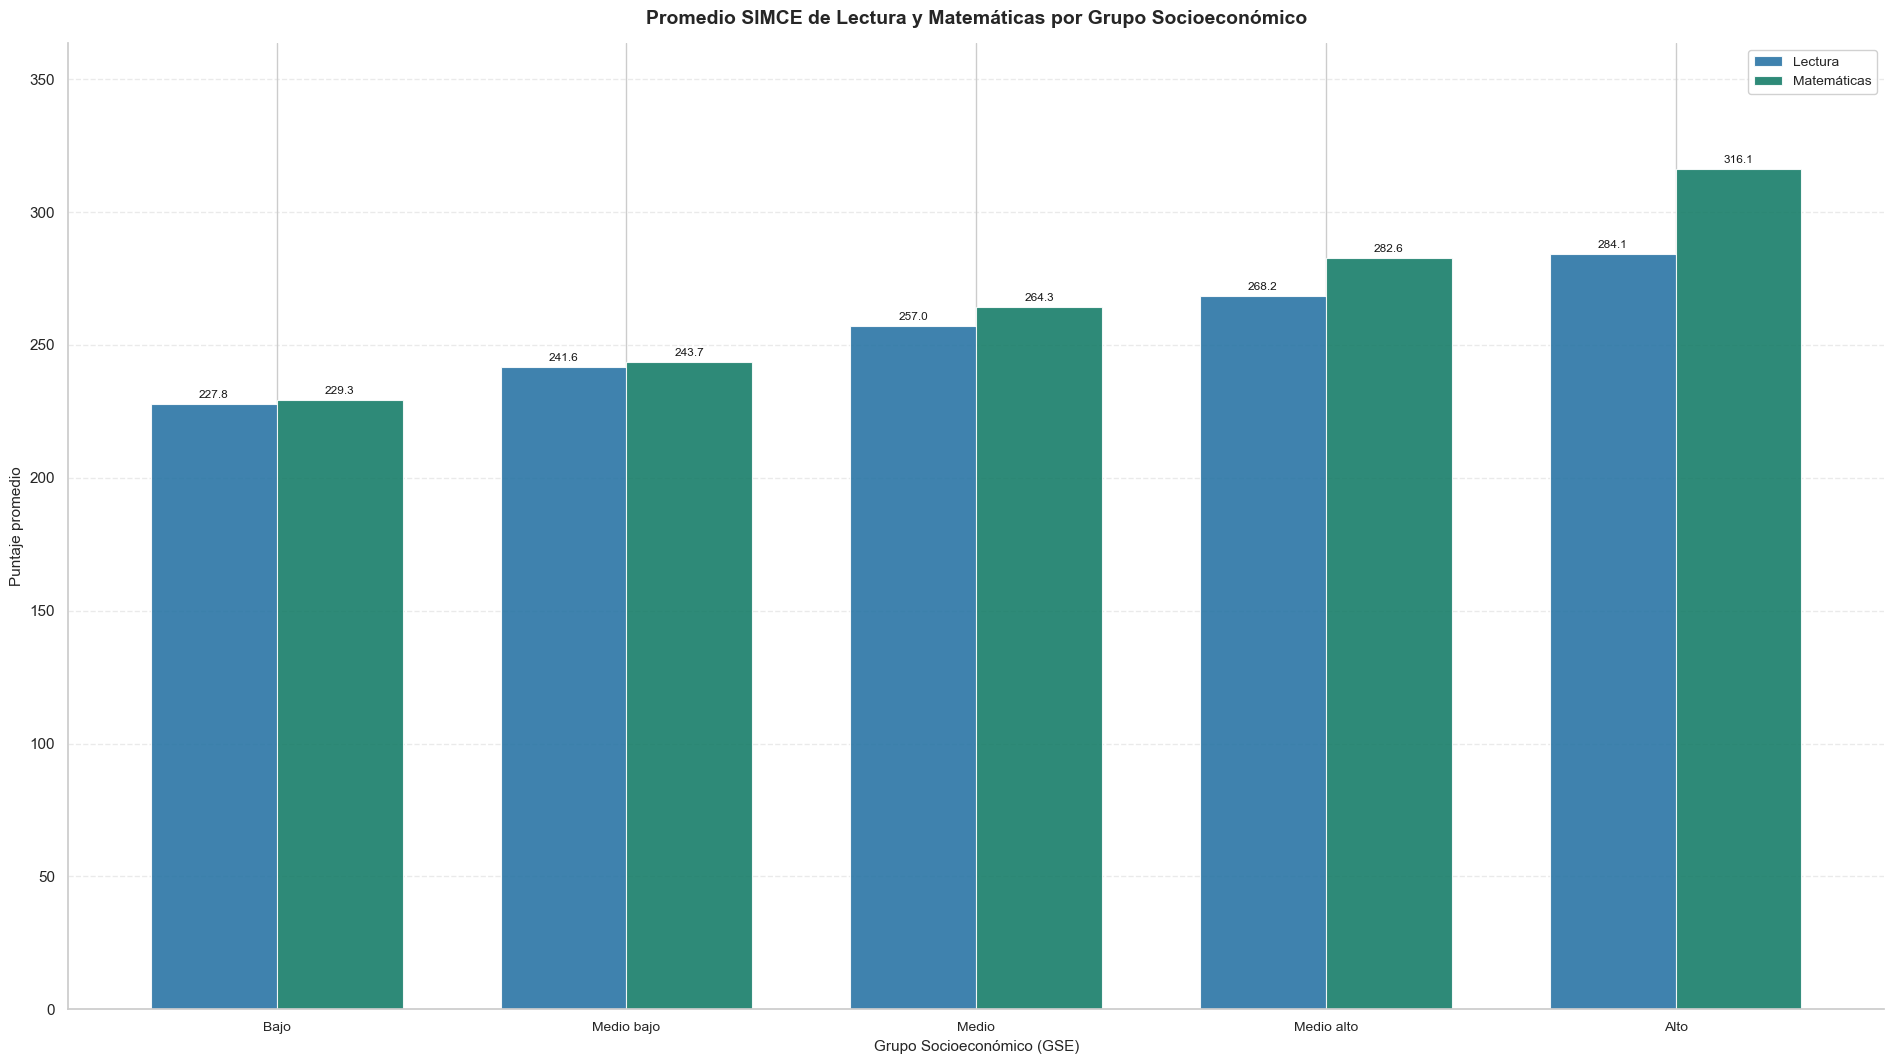

In [128]:
tabla_gse = base_p2.groupby("gse")[["prom_lect2m_rbd", "prom_mate2m_rbd"]].mean().reindex(orden_gse)

x = np.arange(len(orden_gse))
ancho = 0.36
COLOR_LECT = '#2471A3'
COLOR_MATE = '#117A65'

fig, ax = plt.subplots(figsize=(19.1, 10.8))
b1 = ax.bar(x - ancho/2, tabla_gse['prom_lect2m_rbd'], ancho,
            label='Lectura', color=COLOR_LECT, alpha=0.88, edgecolor='white', linewidth=0.8)
b2 = ax.bar(x + ancho/2, tabla_gse['prom_mate2m_rbd'], ancho,
            label='Matemáticas', color=COLOR_MATE, alpha=0.88, edgecolor='white', linewidth=0.8)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.5,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8.5, color='#1a1a1a')

ax.set_title('Promedio SIMCE de Lectura y Matemáticas por Grupo Socioeconómico',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Grupo Socioeconómico (GSE)', fontsize=11)
ax.set_ylabel('Puntaje promedio', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(orden_gse, fontsize=10)
ax.set_ylim(0, tabla_gse.values.max() * 1.15)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('p2_barras_simce_gse.png', dpi=150, bbox_inches='tight')
plt.show()


Los resultados muestran un aumento progresivo en los puntajes promedio de SIMCE a medida que mejora el grupo socioeconómico, tanto en lectura como en matemática. La brecha es mayor en matemática.

/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/4090047348.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/4090047348.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden_gse, fontsize=9)
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/4090047348.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/1r/ff3q597x19966q61h96vcx500000gn/T/ipykernel_23734/4090047348.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks

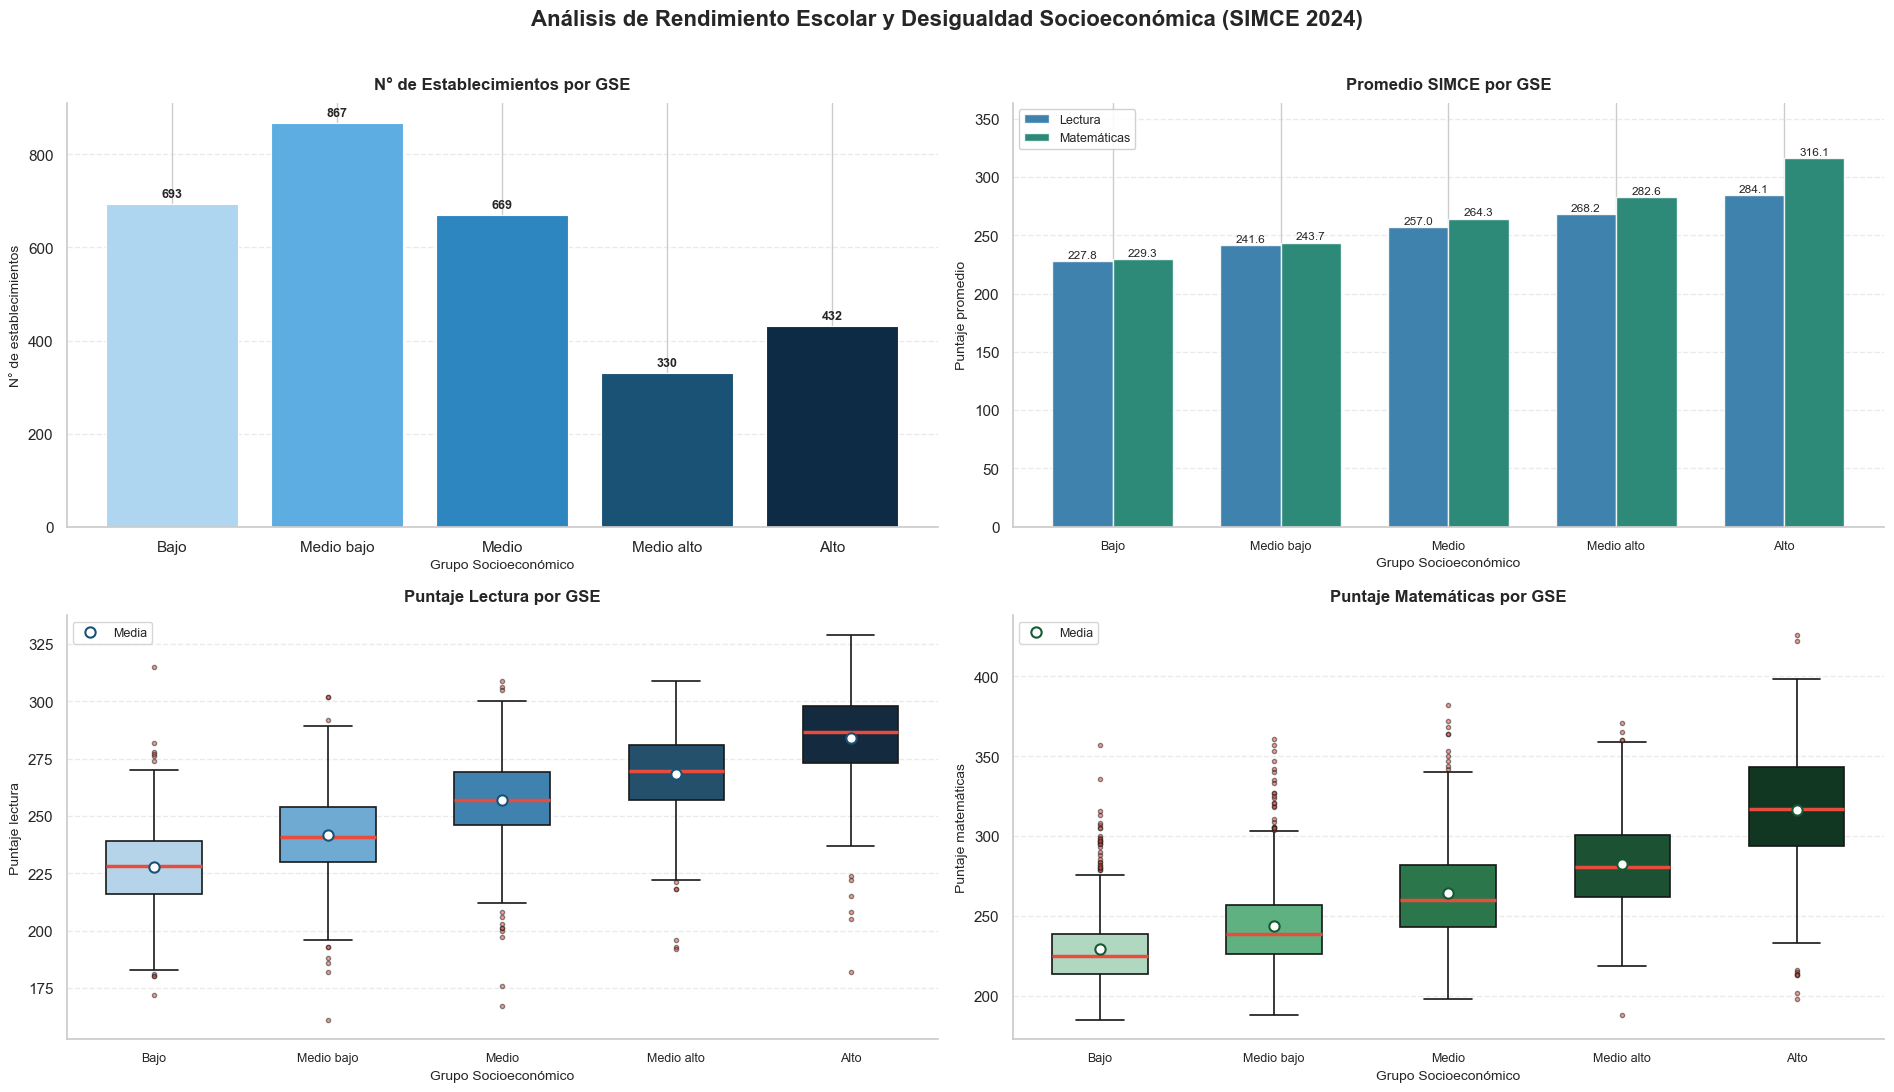

In [ ]:
# ── Figura resumen: los 4 gráficos anteriores juntos ──────────────────
PALETA_GSE       = ["#AED6F1", "#5DADE2", "#2E86C1", "#1A5276", "#0D2B45"]
PALETA_GSE_VERDE = ["#A9DFBF", "#52BE80", "#1E8449", "#145A32", "#0B3D21"]
COLOR_LECT = '#2471A3'
COLOR_MATE = '#117A65'

fig, axes = plt.subplots(2, 2, figsize=(19.6, 10.8))
fig.suptitle('Análisis de Rendimiento Escolar y Desigualdad Socioeconómica (SIMCE 2024)',
             fontsize=16, fontweight='bold', y=1.01)

# ── [0,0] Establecimientos por GSE ────────────────────────────────────
ax = axes[0, 0]
conteos = base_p2['gse'].value_counts().reindex(orden_gse)
bars0 = ax.bar(orden_gse, conteos.values, color=PALETA_GSE, edgecolor='white', linewidth=0.8)
for bar in bars0:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 8,
            f'{int(h):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('N° de Establecimientos por GSE', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Grupo Socioeconómico', fontsize=10)
ax.set_ylabel('N° de establecimientos', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── [0,1] Barras dobles promedio SIMCE ────────────────────────────────
ax = axes[0, 1]
tabla_gse = base_p2.groupby('gse')[['prom_lect2m_rbd', 'prom_mate2m_rbd']].mean().reindex(orden_gse)
x = np.arange(len(orden_gse))
ancho = 0.36
b1 = ax.bar(x - ancho/2, tabla_gse['prom_lect2m_rbd'], ancho,
            label='Lectura', color=COLOR_LECT, alpha=0.88, edgecolor='white')
b2 = ax.bar(x + ancho/2, tabla_gse['prom_mate2m_rbd'], ancho,
            label='Matemáticas', color=COLOR_MATE, alpha=0.88, edgecolor='white')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.1f}', ha='center', va='bottom', fontsize=8.5)
ax.set_title('Promedio SIMCE por GSE', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Grupo Socioeconómico', fontsize=10)
ax.set_ylabel('Puntaje promedio', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(orden_gse, fontsize=9)
ax.set_ylim(0, tabla_gse.values.max() * 1.15)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── [1,0] Boxplot Lectura ─────────────────────────────────────────────
ax = axes[1, 0]
sns.boxplot(
    data=base_p2, x='gse', y='prom_lect2m_rbd', order=orden_gse,
    palette=PALETA_GSE, width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=3, alpha=0.5, linestyle='none'),
    medianprops=dict(color='#E74C3C', linewidth=2.5), ax=ax
)
medias_l = base_p2.groupby('gse')['prom_lect2m_rbd'].mean().reindex(orden_gse)
ax.scatter(range(len(orden_gse)), medias_l.values, color='white', s=55,
           zorder=5, edgecolors='#1A5276', linewidths=1.5, label='Media')
ax.set_title('Puntaje Lectura por GSE', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Grupo Socioeconómico', fontsize=10)
ax.set_ylabel('Puntaje lectura', fontsize=10)
ax.set_xticklabels(orden_gse, fontsize=9)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── [1,1] Boxplot Matemáticas ─────────────────────────────────────────
ax = axes[1, 1]
sns.boxplot(
    data=base_p2, x='gse', y='prom_mate2m_rbd', order=orden_gse,
    palette=PALETA_GSE_VERDE, width=0.55, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=3, alpha=0.5, linestyle='none'),
    medianprops=dict(color='#E74C3C', linewidth=2.5), ax=ax
)
medias_m = base_p2.groupby('gse')['prom_mate2m_rbd'].mean().reindex(orden_gse)
ax.scatter(range(len(orden_gse)), medias_m.values, color='white', s=55,
           zorder=5, edgecolors='#145A32', linewidths=1.5, label='Media')
ax.set_title('Puntaje Matemáticas por GSE', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Grupo Socioeconómico', fontsize=10)
ax.set_ylabel('Puntaje matemáticas', fontsize=10)
ax.set_xticklabels(orden_gse, fontsize=9)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('p2_panel4_gse.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.5 Scatter entre IDPS y lectura

In [ ]:
PALETA_GSE = ["#AED6F1", "#5DADE2", "#2E86C1", "#1A5276", "#0D2B45"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=base_p2, x="AM", y="prom_lect2m_rbd",
    hue="gse", hue_order=orden_gse,
    palette=PALETA_GSE,
    alpha=0.65, s=45, edgecolor='white', linewidth=0.4, ax=ax
)

# Línea de tendencia global
mask = base_p2[["AM", "prom_lect2m_rbd"]].dropna()
m, b = np.polyfit(mask["AM"], mask["prom_lect2m_rbd"], 1)
x_line = np.linspace(mask["AM"].min(), mask["AM"].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2.2,
        linestyle='--', label=f'Tendencia (pendiente={m:.2f})', zorder=5)

corr_am_lect = mask["AM"].corr(mask["prom_lect2m_rbd"])
ax.set_title(f'Autoestima Académica (AM) vs Puntaje de Lectura\n(r = {corr_am_lect:.3f})',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Indicador de Autoestima y Motivación (AM)', fontsize=11)
ax.set_ylabel('Puntaje promedio de lectura', fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='GSE', fontsize=9, title_fontsize=9,
          loc='upper left', framealpha=0.9)
ax.grid(linestyle='--', alpha=0.35)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('p2_scatter_am_lectura.png', dpi=150, bbox_inches='tight')
plt.show()


Se observa una relación positiva leve entre la autoestima académica y el puntaje SIMCE en lectura. La alta dispersión indica que la autoestima no es un factor determinante por sí solo.

### 7.6 Heatmap de correlaciones

In [ ]:
VARS_P2 = ["prom_lect2m_rbd", "prom_mate2m_rbd", "AM", "CC", "HV", "PF"]
LABELS_P2 = ["Lectura", "Matemáticas", "Autoestima (AM)", "Clima escolar (CC)",
             "Hábitos (HV)", "Part. familia (PF)"]

corr_p2 = base_p2[VARS_P2].corr()

mask_upper = np.triu(np.ones_like(corr_p2, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_p2,
    annot=True, fmt='.2f', cmap='RdYlBu_r',
    vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    square=True,
    annot_kws={'size': 11, 'weight': 'bold'},
    xticklabels=LABELS_P2, yticklabels=LABELS_P2,
    ax=ax
)

ax.set_title('Correlación entre Puntajes SIMCE e Indicadores IDPS 2024',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(LABELS_P2, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(LABELS_P2, rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('p2_heatmap_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


## **Histogramas de puntajes SIMCE**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, titulo, etiqueta in [
    (axes[0], 'prom_lect2m_rbd', '#2471A3', 'Distribución Puntaje Lectura SIMCE 2024', 'Puntaje lectura'),
    (axes[1], 'prom_mate2m_rbd', '#117A65', 'Distribución Puntaje Matemáticas SIMCE 2024', 'Puntaje matemáticas'),
]:
    datos = base_p2[col].dropna()
    media = datos.mean()
    mediana = datos.median()

    ax.hist(datos, bins=35, color=color, alpha=0.82, edgecolor='white', linewidth=0.6)
    ax.axvline(media,   color='tomato',  linewidth=2,   linestyle='-',  label=f'Media: {media:.1f}')
    ax.axvline(mediana, color='#E67E22', linewidth=1.8, linestyle='--', label=f'Mediana: {mediana:.1f}')

    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(etiqueta, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribución de Puntajes SIMCE por Establecimiento — 2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('histogramas_simce_p2.png', dpi=150, bbox_inches='tight')
plt.show()


---
<center>

# **Estimación estadística**

</center>

### Parámetros de interés

Se estiman los siguientes parámetros para analizar la relación entre desigualdad socioeconómica y rendimiento escolar:

- **Media y mediana** de puntajes SIMCE de lectura por grupo socioeconómico (GSE)
- **Desviación estándar** de los puntajes en cada grupo
- **Intervalo de confianza al 95%** para la media de puntajes por GSE
- **Media** de puntajes por tipo de dependencia (municipal, subvencionado, particular)

In [ ]:
import scipy.stats as stats

orden_gse2 = ["Bajo", "Medio bajo", "Medio", "Medio alto", "Alto"]

estimadores2 = []
for gse, grupo in base_p2.groupby('gse')['prom_lect2m_rbd']:
    n = len(grupo.dropna())
    if n < 2:
        continue
    media = grupo.mean()
    mediana = grupo.median()
    std = grupo.std()
    se = std / np.sqrt(n)
    ic_low, ic_high = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    estimadores2.append({
        'GSE': gse,
        'N': n,
        'Media lectura': round(media, 1),
        'Mediana': round(mediana, 1),
        'Desv. Std': round(std, 1),
        'IC 95% inf': round(ic_low, 1),
        'IC 95% sup': round(ic_high, 1),
    })

tabla_est2 = pd.DataFrame(estimadores2).set_index('GSE')
tabla_est2 = tabla_est2.reindex([g for g in orden_gse2 if g in tabla_est2.index])
print("Estimadores del puntaje de lectura por Grupo Socioeconómico:")
display(tabla_est2)


In [ ]:
# Estimadores por dependencia (municipal, subvencionado, particular)
est_dep2 = base_p2.groupby('dependencia')['prom_lect2m_rbd'].agg(
    N='count',
    Media=lambda x: round(x.mean(), 1),
    Mediana=lambda x: round(x.median(), 1),
    Desv_Std=lambda x: round(x.std(), 1)
).rename(columns={'Desv_Std': 'Desv. Std'})

print("Puntaje lectura promedio por tipo de dependencia:")
display(est_dep2)


In [ ]:
# Tabla resumen general - Pregunta 2
corr_am2 = base_p2['AM'].corr(base_p2['prom_lect2m_rbd'])
media_muni = base_p2[base_p2['dependencia']=='Municipal']['prom_lect2m_rbd'].mean()
media_part = base_p2[base_p2['dependencia']=='Particular pagado']['prom_lect2m_rbd'].mean()

resumen2 = pd.DataFrame({
    'Estimador': [
        'Media puntaje lectura (global)',
        'Mediana puntaje lectura (global)',
        'Media puntaje matemáticas (global)',
        'Media lectura — Municipal',
        'Media lectura — Particular pagado',
        'Correlación Pearson (AM vs lectura)',
        '% establecimientos municipales',
    ],
    'Valor': [
        round(base_p2['prom_lect2m_rbd'].mean(), 1),
        round(base_p2['prom_lect2m_rbd'].median(), 1),
        round(base_p2['prom_mate2m_rbd'].mean(), 1),
        round(media_muni, 1),
        round(media_part, 1),
        round(corr_am2, 3),
        f"{(base_p2['dependencia']=='Municipal').mean()*100:.1f}%",
    ]
})
print("=== TABLA RESUMEN — PREGUNTA 2 ===")
display(resumen2.set_index('Estimador'))


<center>

# **Identificación**
</center>

Existe una relación clara entre el grupo socioeconómico del establecimiento y el rendimiento académico medido por SIMCE. A mayor nivel socioeconómico, mejores resultados en lectura y matemática. Los indicadores IDPS muestran relaciones débiles a moderadas, siendo el clima de convivencia escolar el de mayor correlación.

<br>

---
<center>

# **Pregunta 3**
# **¿La urbanización se asocia con niveles más altos de contaminación?**

</center>

### Datasets:

In [ ]:
path3 = "basesDeDatos/pregunta_3/"
poblacion3     = pd.read_csv(path3 + "Base_urbanos_CPV24.csv", sep=";")
contaminacion3 = pd.read_excel(path3 + "efd-ckan-2023.xlsx")

<center>

# **Limpieza de datos**
</center>

## **Valores ausentes**

In [ ]:
print("DATAFRAME DE POBLACIÓN URBANA (CPV 2024):")
display(poblacion3.isnull().sum())
print("================================================================")
print("DATAFRAME DE CONTAMINACIÓN (EFD 2023):")
display(contaminacion3.isnull().sum())

El dataframe de población no presenta nulos en las columnas de interés. El dataframe de contaminación tiene nulos en Latitud y Longitud, que no se utilizarán. Nos quedamos con la población total y las toneladas emitidas, ambas agrupadas por comuna.

In [ ]:
poblacion3 = poblacion3.groupby("COMUNA")["n_per"].sum().to_frame("poblacion_total")
poblacion3.index = [i.lower() for i in poblacion3.index]
poblacion3.index.name = "comuna"

contaminacion3 = contaminacion3.groupby("comuna")["cantidad_toneladas"].sum().to_frame("cantidad_total_toneladas")
contaminacion3.index = [i.lower() for i in contaminacion3.index]
contaminacion3.index.name = "comuna" 

## **Outliers**

In [ ]:
IQR_pob3  = poblacion3.quantile(0.75)     - poblacion3.quantile(0.25)
IQR_cont3 = contaminacion3.quantile(0.75) - contaminacion3.quantile(0.25)

limite_superior_pob3  = poblacion3.quantile(0.75)     + 1.5 * IQR_pob3
limite_inferior_pob3  = poblacion3.quantile(0.25)     - 1.5 * IQR_pob3
limite_superior_cont3 = contaminacion3.quantile(0.75) + 1.5 * IQR_cont3
limite_inferior_cont3 = contaminacion3.quantile(0.25) - 1.5 * IQR_cont3

outliers_pob3 = poblacion3[
    (poblacion3["poblacion_total"] > limite_superior_pob3["poblacion_total"]) |
    (poblacion3["poblacion_total"] < limite_inferior_pob3["poblacion_total"])
]
outliers_cont3 = contaminacion3[
    (contaminacion3["cantidad_total_toneladas"] > limite_superior_cont3["cantidad_total_toneladas"]) |
    (contaminacion3["cantidad_total_toneladas"] < limite_inferior_cont3["cantidad_total_toneladas"])
]

print("Outliers en población urbana:")
display(outliers_pob3.shape[0])
print("Outliers en contaminación:")
display(outliers_cont3.shape[0])

<center>

# **Estadísticas descriptivas**

</center>

In [ ]:
print("POBLACIÓN URBANA POR COMUNA:")
display(poblacion3.describe())
print("================================================================")
print("CONTAMINACIÓN POR COMUNA:")
display(contaminacion3.describe())

<center>

# **Visualizaciones**

</center>

Para esto vamos a unir los dos dataframes

In [ ]:
union3 = pd.merge(contaminacion3, poblacion3, left_on="comuna", right_on="comuna", how="inner")

# **Scatter**
Esto se utiliza para poder ver la relación entre la contaminación total y la población urbana por comuna

In [ ]:
outlier3 = union3["cantidad_total_toneladas"].idxmax()
union3_plot = union3.drop(index=outlier3)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    union3_plot["cantidad_total_toneladas"],
    union3_plot["poblacion_total"],
    color="steelblue", alpha=0.7, edgecolors="white", s=80, zorder=3
)

m, b = np.polyfit(union3_plot["cantidad_total_toneladas"], union3_plot["poblacion_total"], 1)
x_line = np.linspace(union3_plot["cantidad_total_toneladas"].min(),
                     union3_plot["cantidad_total_toneladas"].max(), 200)
ax.plot(x_line, m * x_line + b, color="tomato", linewidth=2,
        label=f"Tendencia (pendiente={m:.2f})")

ax.set_xlabel("Contaminación total (toneladas)", fontsize=12)
ax.set_ylabel("Población total", fontsize=12)
ax.set_title("¿A mayor población, mayor contaminación?\n(por comuna, 2023)", fontsize=13)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

corr3 = union3_plot["cantidad_total_toneladas"].corr(union3_plot["poblacion_total"])
print(f"Correlación de Pearson: {corr3:.3f}")

## **Histogramas y Boxplots**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma contaminación (sin outlier mayor)
axes[0, 0].hist(union3_plot['cantidad_total_toneladas'], bins=30, color='#C0392B', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Distribución de Emisiones Contaminantes por Comuna', fontsize=11)
axes[0, 0].set_xlabel('Toneladas emitidas')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.4)

# Histograma población
axes[0, 1].hist(union3_plot['poblacion_total'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Distribución de Población Urbana por Comuna', fontsize=11)
axes[0, 1].set_xlabel('Población total')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.4)

# Boxplot contaminación
axes[1, 0].boxplot(union3_plot['cantidad_total_toneladas'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#C0392B', alpha=0.7))
axes[1, 0].set_title('Boxplot: Emisiones por Comuna', fontsize=11)
axes[1, 0].set_ylabel('Toneladas emitidas')
axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Boxplot población
axes[1, 1].boxplot(union3_plot['poblacion_total'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1, 1].set_title('Boxplot: Población Urbana por Comuna', fontsize=11)
axes[1, 1].set_ylabel('Población total')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('histogramas_boxplots_p3.png', dpi=150, bbox_inches='tight')
plt.show()


---
<center>

# **Estimación estadística**

</center>

### Parámetros de interés

Se estiman los siguientes parámetros para analizar la relación entre urbanización y contaminación:

- **Media y mediana** de las emisiones contaminantes por categoría de tamaño de ciudad
- **Desviación estándar** de las emisiones dentro de cada grupo
- **Intervalo de confianza al 95%** para la media de emisiones por categoría
- **Correlación de Pearson** entre población y contaminación

In [ ]:
import scipy.stats as stats

# Categorizar comunas por tamaño de población
union3_plot['tamaño'] = pd.cut(
    union3_plot['poblacion_total'],
    bins=[0, 20_000, 100_000, 500_000, float('inf')],
    labels=['Pequeña (<20k)', 'Mediana (20k-100k)', 'Grande (100k-500k)', 'Metrópoli (>500k)']
)

estimadores3 = []
for nombre, grupo in union3_plot.groupby('tamaño')['cantidad_total_toneladas']:
    n = len(grupo)
    if n < 2:
        continue
    media = grupo.mean()
    mediana = grupo.median()
    std = grupo.std()
    se = std / np.sqrt(n)
    ic_low, ic_high = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    estimadores3.append({
        'Tamaño ciudad': str(nombre),
        'N': n,
        'Media emisiones (ton)': round(media, 0),
        'Mediana (ton)': round(mediana, 0),
        'Desv. Std': round(std, 0),
        'IC 95% inf': round(ic_low, 0),
        'IC 95% sup': round(ic_high, 0),
    })

tabla_est3 = pd.DataFrame(estimadores3).set_index('Tamaño ciudad')
print("Estimadores de emisiones contaminantes por tamaño de ciudad:")
display(tabla_est3)


In [ ]:
# Tabla resumen general - Pregunta 3
corr3 = union3_plot['cantidad_total_toneladas'].corr(union3_plot['poblacion_total'])

resumen3 = pd.DataFrame({
    'Estimador': [
        'Media emisiones por comuna (ton)',
        'Mediana emisiones por comuna (ton)',
        'Media población urbana por comuna',
        'Mediana población urbana por comuna',
        'Correlación Pearson (población vs emisiones)',
    ],
    'Valor': [
        f"{union3_plot['cantidad_total_toneladas'].mean():,.0f}",
        f"{union3_plot['cantidad_total_toneladas'].median():,.0f}",
        f"{union3_plot['poblacion_total'].mean():,.0f}",
        f"{union3_plot['poblacion_total'].median():,.0f}",
        round(corr3, 3),
    ]
})
print("=== TABLA RESUMEN — PREGUNTA 3 ===")
display(resumen3.set_index('Estimador'))


<center>

# **Identificación**
</center>

La correlación de Pearson entre contaminación y población urbana es prácticamente nula, indicando que no existe una relación lineal entre el tamaño poblacional de una comuna y sus niveles de contaminación. La contaminación está determinada principalmente por el tipo de fuentes industriales presentes, no por la cantidad de habitantes.

<br>

---
<center>

# **Pregunta 4**
# **¿El nivel de ingreso predice el acceso a la educación superior?**

</center>

### Datasets:

In [ ]:
path4 = "basesDeDatos/pregunta_4/"
casen = pd.read_csv(path4 + "casen_2022_Limpio.csv")

<center>

# **Limpieza de datos**
</center>

## **Valores ausentes**

In [ ]:
print("DATAFRAME CASEN 2022:")
display(casen.isnull().sum())

El dataset no presenta nulos. Se filtran personas mayores de 18 años con código educacional válido (`educc > -88`). Se crean etiquetas para los niveles educacionales y de pobreza, y una variable binaria que indica si la persona tiene educación superior.

In [ ]:
df4 = casen[(casen["edad"] >= 18) & (casen["educc"] > -88)].copy()

edu_labels = {
    0: "Sin ed.\nformal",
    1: "Básica\nincompleta",
    2: "Básica\ncompleta",
    3: "Media\nincompleta",
    4: "Media\ncompleta",
    5: "Superior\nincompleta",
    6: "Superior\ncompleta"
}

pob_labels = {
    1.0: "Pobre\nExtremo",
    2.0: "Pobre no\nExtremo",
    3.0: "No Pobre"
}

df4["tiene_superior"] = df4["educc"] >= 5

## **Outliers**

In [ ]:
IQR_income4 = df4["ypchtotcor"].quantile(0.75) - df4["ypchtotcor"].quantile(0.25)
IQR_educc4  = df4["educc"].quantile(0.75)       - df4["educc"].quantile(0.25)

limite_sup_income4 = df4["ypchtotcor"].quantile(0.75) + 1.5 * IQR_income4
limite_inf_income4 = df4["ypchtotcor"].quantile(0.25) - 1.5 * IQR_income4
limite_sup_educc4  = df4["educc"].quantile(0.75)       + 1.5 * IQR_educc4
limite_inf_educc4  = df4["educc"].quantile(0.25)       - 1.5 * IQR_educc4

outliers_income4 = df4[
    (df4["ypchtotcor"] > limite_sup_income4) |
    (df4["ypchtotcor"] < limite_inf_income4)
]
outliers_educc4 = df4[
    (df4["educc"] > limite_sup_educc4) |
    (df4["educc"] < limite_inf_educc4)
]

print("Outliers en ingreso per cápita:")
display(outliers_income4.shape[0])
print("Outliers en nivel educacional:")
display(outliers_educc4.shape[0])

<center>

# **Estadísticas descriptivas**

</center>

In [ ]:
display(df4[["edad", "ypchtotcor", "educc", "pobreza"]].describe())

<center>

# **Visualizaciones**

</center>

### Gráfico 1: Distribución del ingreso per cápita por nivel educacional

In [ ]:
p95 = df4["ypchtotcor"].quantile(0.95)
df4_plot = df4[df4["ypchtotcor"] <= p95]

niveles4 = sorted(df4_plot["educc"].unique())
data_box4 = [df4_plot[df4_plot["educc"] == n]["ypchtotcor"].values for n in niveles4]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(data_box4, patch_artist=True, medianprops=dict(color="black", linewidth=2))

colors4 = plt.cm.RdYlGn([i / (len(niveles4) - 1) for i in range(len(niveles4))])
for patch, color in zip(bp["boxes"], colors4):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, len(niveles4) + 1))
ax.set_xticklabels([edu_labels[n] for n in niveles4], fontsize=9)
ax.set_xlabel("Nivel educacional", fontsize=12)
ax.set_ylabel("Ingreso per cápita (CLP)", fontsize=12)
ax.set_title("Distribución del ingreso per cápita según nivel educacional\n(hasta percentil 95)", fontsize=13)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 2: Proporción con educación superior según nivel de pobreza

In [ ]:
prop4 = df4.groupby("pobreza")["tiene_superior"].mean() * 100
grupos4 = sorted(prop4.index)
valores4 = [prop4[g] for g in grupos4]
etiquetas4 = [pob_labels[g] for g in grupos4]
colores4 = ["#d73027", "#fc8d59", "#4dac26"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(etiquetas4, valores4, color=colores4, width=0.5, edgecolor="white")

for bar, val in zip(bars, valores4):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, max(valores4) * 1.2)
ax.set_xlabel("Nivel de pobreza", fontsize=12)
ax.set_ylabel("Personas con educación superior (%)", fontsize=12)
ax.set_title("Proporción con educación superior\nsegún nivel de pobreza", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Gráfico 3: Distribución del nivel educacional por grupo de pobreza

In [ ]:
tabla4 = df4.groupby(["pobreza", "educc"]).size().unstack(fill_value=0)
tabla_pct4 = tabla4.div(tabla4.sum(axis=1), axis=0) * 100
cols4  = sorted(tabla_pct4.columns)
filas4 = sorted(tabla_pct4.index)
tabla_pct4 = tabla_pct4[cols4].loc[filas4]

colores_edu4 = ["#d73027", "#f46d43", "#fdae61", "#fee08b", "#d9ef8b", "#66bd63", "#1a9850"]

fig, ax = plt.subplots(figsize=(9, 6))
bottom4 = [0] * len(filas4)

for i, nivel in enumerate(cols4):
    vals = [tabla_pct4.loc[f, nivel] for f in filas4]
    bars = ax.bar(range(len(filas4)), vals, bottom=bottom4,
                  color=colores_edu4[i], label=edu_labels[nivel], edgecolor="white")
    for j, (val, bot) in enumerate(zip(vals, bottom4)):
        if val > 4:
            ax.text(j, bot + val / 2, f"{val:.1f}%", ha="center", va="center",
                    fontsize=7.5, color="black", fontweight="bold")
    bottom4 = [b + v for b, v in zip(bottom4, vals)]

ax.set_xticks(range(len(filas4)))
ax.set_xticklabels([pob_labels[f] for f in filas4], fontsize=11)
ax.set_ylabel("Porcentaje (%)", fontsize=12)
ax.set_title("Distribución del nivel educacional\npor grupo de pobreza", fontsize=13)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9, title="Nivel educacional")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## **Histograma de distribución del ingreso per cápita**

In [ ]:
p95_4 = df4["ypchtotcor"].quantile(0.95)
df4_hist = df4[df4["ypchtotcor"] <= p95_4]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df4_hist["ypchtotcor"], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_title('Distribución del Ingreso Per Cápita (hasta percentil 95)', fontsize=13)
ax.set_xlabel('Ingreso per cápita mensual (CLP)')
ax.set_ylabel('Frecuencia')
ax.axvline(df4_hist["ypchtotcor"].mean(), color='tomato', linewidth=2,
           label=f"Media: ${df4_hist['ypchtotcor'].mean():,.0f}")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('histograma_ingreso_p4.png', dpi=150, bbox_inches='tight')
plt.show()


---
<center>

# **Estimación estadística**

</center>

### Parámetros de interés

Se estiman los siguientes parámetros para analizar la relación entre nivel educacional e ingreso:

- **Media y mediana** del ingreso per cápita por nivel educacional
- **Desviación estándar** como medida de dispersión salarial en cada nivel
- **Intervalo de confianza al 95%** para la media de ingreso en cada grupo
- **Proporción** de personas con educación superior por grupo de pobreza

In [ ]:
import scipy.stats as stats

edu_labels4 = {
    0: 'Sin educación', 1: 'Básica incompleta', 2: 'Básica completa',
    3: 'Media incompleta', 4: 'Media completa',
    5: 'Superior incompleta', 6: 'Superior completa'
}

estimadores4 = []
for nivel, grupo in df4.groupby('educc')['ypchtotcor']:
    n = len(grupo)
    media = grupo.mean()
    mediana = grupo.median()
    std = grupo.std()
    se = std / np.sqrt(n)
    ic_low, ic_high = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    estimadores4.append({
        'Nivel educacional': edu_labels4.get(nivel, str(nivel)),
        'N': n,
        'Media ingreso ($)': round(media, 0),
        'Mediana ($)': round(mediana, 0),
        'Desv. Std': round(std, 0),
        'IC 95% inf': round(ic_low, 0),
        'IC 95% sup': round(ic_high, 0),
    })

tabla_est4 = pd.DataFrame(estimadores4).set_index('Nivel educacional')
print("Estimadores del ingreso per cápita por nivel educacional:")
display(tabla_est4)


In [ ]:
# Proporción con educación superior por grupo de pobreza
pob_labels4 = {1.0: 'Pobre Extremo', 2.0: 'Pobre no Extremo', 3.0: 'No Pobre'}

prop_sup4 = df4.groupby('pobreza')['tiene_superior'].agg(['mean', 'count'])
prop_sup4['mean'] = (prop_sup4['mean'] * 100).round(1)
prop_sup4.index = [pob_labels4.get(i, str(i)) for i in prop_sup4.index]
prop_sup4.columns = ['% con educación superior', 'N']
print("Proporción con educación superior por grupo de pobreza:")
display(prop_sup4)


In [ ]:
# Tabla resumen general - Pregunta 4
media_no_pobre4    = df4[df4['pobreza'] == 3.0]['ypchtotcor'].mean()
media_pobre_ext4   = df4[df4['pobreza'] == 1.0]['ypchtotcor'].mean()
corr_edu_ing       = df4['educc'].corr(df4['ypchtotcor'])

resumen4 = pd.DataFrame({
    'Estimador': [
        'Media ingreso per cápita general',
        'Mediana ingreso per cápita general',
        'Media ingreso — No Pobre',
        'Media ingreso — Pobre Extremo',
        '% con superior — No Pobre',
        '% con superior — Pobre Extremo',
        'Correlación Pearson (educc vs ingreso)',
    ],
    'Valor': [
        f"${df4['ypchtotcor'].mean():,.0f}",
        f"${df4['ypchtotcor'].median():,.0f}",
        f"${media_no_pobre4:,.0f}",
        f"${media_pobre_ext4:,.0f}",
        f"{df4[df4['pobreza']==3.0]['tiene_superior'].mean()*100:.1f}%",
        f"{df4[df4['pobreza']==1.0]['tiene_superior'].mean()*100:.1f}%",
        round(corr_edu_ing, 3),
    ]
})
print("=== TABLA RESUMEN — PREGUNTA 4 ===")
display(resumen4.set_index('Estimador'))


<center>

# **Identificación**
</center>

Se observa una relación clara entre el nivel educacional y el ingreso per cápita: a mayor educación, mayor ingreso. El acceso a educación superior es significativamente más alto entre personas no pobres que entre personas en situación de pobreza extrema, lo que confirma que el nivel de ingreso predice el acceso a la educación superior.

<br>

---
<center>

# **Pregunta 5**
# **¿Las ciudades más grandes tendrán mayor índice de pobreza?**

</center>

### Datasets:

In [ ]:
path5 = "basesDeDatos/pregunta_5/"
poblacion5 = pd.read_csv(path5 + "Base_urbanos_CPV24.csv", sep=";")
pobreza5   = pd.read_excel(path5 + "Estimaciones_Indice_Pobreza_Multidimensional_Comunas_2022.xlsx", header=2)

<center>

# **Limpieza de datos**
</center>

## **Valores ausentes**

In [ ]:
print("DATAFRAME DE POBLACIÓN URBANA (CPV 2024):")
display(poblacion5.isnull().sum())
print("================================================================")
print("DATAFRAME DE POBREZA MULTIDIMENSIONAL (2022):")
display(pobreza5.isnull().sum())

El dataframe de población no tiene nulos. El de pobreza tiene filas nulas al final (notas del Excel) que se eliminan. Se agrupa por comuna, se hace el merge, se calcula la tasa de pobreza y se categoriza el tamaño de cada ciudad.

In [ ]:
# Población por comuna
poblacion5 = poblacion5.groupby("COMUNA")["n_per"].sum().to_frame("poblacion_total")
poblacion5.index = [i.lower() for i in poblacion5.index]
poblacion5.index.name = "comuna"

# Pobreza por comuna
pobreza5 = pobreza5.dropna(subset=["Nombre comuna"])
pobreza5_grp = pobreza5.groupby("Nombre comuna")[
    "Número de personas en situación de pobreza multidimensional (**)"].sum().to_frame("pobreza_multidimensional")
pobreza5_grp.index = [str(i).lower() for i in pobreza5_grp.index]
pobreza5_grp.index.name = "comuna"

# Merge y cálculo de tasa de pobreza
df5 = pd.merge(poblacion5, pobreza5_grp, left_index=True, right_index=True, how="inner")
df5["tasa_pobreza"] = (df5["pobreza_multidimensional"] / df5["poblacion_total"]) * 100
df5 = df5.sort_values("poblacion_total", ascending=False)

# Categorizar por tamaño de ciudad
bins5   = [0, 10_000, 50_000, 200_000, float("inf")]
labels5 = ["Pequeña\n(<10k)", "Mediana\n(10k–50k)", "Grande\n(50k–200k)", "Muy grande\n(>200k)"]
df5["tamaño"] = pd.cut(df5["poblacion_total"], bins=bins5, labels=labels5)

## **Outliers**

In [ ]:
IQR_pob5  = df5["poblacion_total"].quantile(0.75) - df5["poblacion_total"].quantile(0.25)
IQR_tasa5 = df5["tasa_pobreza"].quantile(0.75)    - df5["tasa_pobreza"].quantile(0.25)

limite_sup_pob5  = df5["poblacion_total"].quantile(0.75) + 1.5 * IQR_pob5
limite_inf_pob5  = df5["poblacion_total"].quantile(0.25) - 1.5 * IQR_pob5
limite_sup_tasa5 = df5["tasa_pobreza"].quantile(0.75)    + 1.5 * IQR_tasa5
limite_inf_tasa5 = df5["tasa_pobreza"].quantile(0.25)    - 1.5 * IQR_tasa5

outliers_pob5 = df5[
    (df5["poblacion_total"] > limite_sup_pob5) |
    (df5["poblacion_total"] < limite_inf_pob5)
]
outliers_tasa5 = df5[
    (df5["tasa_pobreza"] > limite_sup_tasa5) |
    (df5["tasa_pobreza"] < limite_inf_tasa5)
]

print("Outliers en población urbana:")
display(outliers_pob5.shape[0])
print("Outliers en tasa de pobreza:")
display(outliers_tasa5.shape[0])

<center>

# **Estadísticas descriptivas**

</center>

In [ ]:
display(df5[["poblacion_total", "pobreza_multidimensional", "tasa_pobreza"]].describe())

<center>

# **Visualizaciones**

</center>

## Gráfico 1 — Dispersión: Población vs Pobreza

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: pobreza absoluta
axes[0].scatter(df5["poblacion_total"], df5["pobreza_multidimensional"],
                alpha=0.5, color="steelblue", edgecolors="none")
z0 = np.polyfit(df5["poblacion_total"], df5["pobreza_multidimensional"], 1)
x_line5 = np.linspace(df5["poblacion_total"].min(), df5["poblacion_total"].max(), 200)
axes[0].plot(x_line5, np.poly1d(z0)(x_line5), "r--", linewidth=1.5, label="Tendencia")
axes[0].set_xlabel("Población total")
axes[0].set_ylabel("Personas en pobreza multidimensional")
axes[0].set_title("Población vs Pobreza absoluta")
axes[0].legend()

# Panel derecho: tasa de pobreza
axes[1].scatter(df5["poblacion_total"], df5["tasa_pobreza"],
                alpha=0.5, color="darkorange", edgecolors="none")
z1 = np.polyfit(df5["poblacion_total"], df5["tasa_pobreza"], 1)
axes[1].plot(x_line5, np.poly1d(z1)(x_line5), "r--", linewidth=1.5, label="Tendencia")
axes[1].set_xlabel("Población total")
axes[1].set_ylabel("Tasa de pobreza multidimensional (%)")
axes[1].set_title("Población vs Tasa de pobreza (%)")
axes[1].legend()

plt.suptitle("¿Las ciudades más grandes tienen mayor pobreza?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("scatter_poblacion_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfico 2 — Distribución por tamaño de ciudad (boxplot)

In [ ]:
colores5 = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

fig, ax = plt.subplots(figsize=(10, 6))
grupos5 = [df5[df5["tamaño"] == t]["tasa_pobreza"].dropna() for t in labels5]
bp5 = ax.boxplot(grupos5, labels=labels5, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp5["boxes"], colores5):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel("Tamaño de ciudad (por población)", fontsize=12)
ax.set_ylabel("Tasa de pobreza multidimensional (%)", fontsize=12)
ax.set_title("Distribución de la tasa de pobreza según tamaño de ciudad", fontsize=14, fontweight="bold")

for i, grupo in enumerate(grupos5, 1):
    mediana = grupo.median()
    ax.text(i, mediana + 0.3, f"{mediana:.1f}%", ha="center", va="bottom", fontsize=9, color="black")

plt.tight_layout()
plt.savefig("boxplot_tamaño_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()

## Gráfico 3 — Top 10 comunas con mayor y menor tasa de pobreza

In [ ]:
top10_p5    = df5.nlargest(10, "tasa_pobreza").sort_values("tasa_pobreza")
bottom10_p5 = df5.nsmallest(10, "tasa_pobreza").sort_values("tasa_pobreza", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mayor tasa
bars0 = axes[0].barh(top10_p5.index.str.title(), top10_p5["tasa_pobreza"], color="#e15759", alpha=0.85)
for bar, pob in zip(bars0, top10_p5["poblacion_total"]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"  pob: {pob:,.0f}", va="center", fontsize=8, color="gray")
axes[0].set_title("10 comunas con MAYOR tasa de pobreza", fontweight="bold")
axes[0].set_xlabel("Tasa de pobreza multidimensional (%)")
axes[0].set_xlim(0, top10_p5["tasa_pobreza"].max() * 1.35)

# Menor tasa
bars1 = axes[1].barh(bottom10_p5.index.str.title(), bottom10_p5["tasa_pobreza"], color="#59a14f", alpha=0.85)
for bar, pob in zip(bars1, bottom10_p5["poblacion_total"]):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f"  pob: {pob:,.0f}", va="center", fontsize=8, color="gray")
axes[1].set_title("10 comunas con MENOR tasa de pobreza", fontweight="bold")
axes[1].set_xlabel("Tasa de pobreza multidimensional (%)")
axes[1].set_xlim(0, bottom10_p5["tasa_pobreza"].max() * 1.35)

plt.tight_layout()
plt.savefig("barras_top10_pobreza.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlación y conclusión

In [ ]:
corr_abs5  = df5["poblacion_total"].corr(df5["pobreza_multidimensional"])
corr_tasa5 = df5["poblacion_total"].corr(df5["tasa_pobreza"])

print(f"Correlación población ↔ pobreza absoluta : {corr_abs5:.4f}")
print(f"Correlación población ↔ tasa de pobreza  : {corr_tasa5:.4f}")
print()
print("Tasa de pobreza media por tamaño de ciudad:")
print(df5.groupby("tamaño", observed=True)["tasa_pobreza"].agg(["median", "mean"]).rename(
    columns={"median": "mediana (%)", "mean": "promedio (%)"}).round(2))

## **Histogramas de variables clave**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df5['poblacion_total'], bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de Población Urbana por Comuna', fontsize=12)
axes[0].set_xlabel('Población total')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

axes[1].hist(df5['tasa_pobreza'], bins=30, color='#C0392B', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribución de Tasa de Pobreza Multidimensional (%)', fontsize=12)
axes[1].set_xlabel('Tasa de pobreza (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('histogramas_poblacion_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()


---
<center>

# **Estimación estadística**

</center>

### Parámetros de interés

Se estiman los siguientes parámetros para analizar la relación entre tamaño de ciudad y pobreza:

- **Media y mediana** de la tasa de pobreza por categoría de tamaño de ciudad
- **Desviación estándar** dentro de cada grupo
- **Intervalo de confianza al 95%** para la media de cada grupo (distribución t)
- **Proporción** de comunas con tasa de pobreza superior al 30%

In [ ]:
import scipy.stats as stats

estimadores5 = []
for nombre, grupo in df5.groupby('tamaño')['tasa_pobreza']:
    n = len(grupo)
    media = grupo.mean()
    mediana = grupo.median()
    std = grupo.std()
    se = std / np.sqrt(n)
    ic_low, ic_high = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    estimadores5.append({
        'Tamaño ciudad': nombre,
        'N': n,
        'Media (%)': round(media, 2),
        'Mediana (%)': round(mediana, 2),
        'Desv. Std': round(std, 2),
        'IC 95% inf': round(ic_low, 2),
        'IC 95% sup': round(ic_high, 2),
    })

tabla_est5 = pd.DataFrame(estimadores5).set_index('Tamaño ciudad')
print("Estimadores de tasa de pobreza por tamaño de ciudad:")
display(tabla_est5)


In [ ]:
# Proporción de comunas con alta pobreza (>30%)
umbral5 = 30
prop_global = (df5['tasa_pobreza'] > umbral5).mean() * 100
print(f"Proporción global de comunas con tasa de pobreza > {umbral5}%: {prop_global:.1f}%\n")

prop_por_tam = df5.groupby('tamaño').apply(
    lambda g: (g['tasa_pobreza'] > umbral5).mean() * 100
).round(1).to_frame('% pobreza > 30%')
print("Por tamaño de ciudad:")
display(prop_por_tam)


In [ ]:
# Tabla resumen general - Pregunta 5
corr_tasa5 = df5['poblacion_total'].corr(df5['tasa_pobreza'])

resumen5 = pd.DataFrame({
    'Estimador': [
        'Media tasa de pobreza (%)',
        'Mediana tasa de pobreza (%)',
        'Desv. Std tasa de pobreza',
        'Media población urbana por comuna',
        'Correlación Pearson (población vs tasa pobreza)',
        'Proporción comunas con pobreza > 30%',
    ],
    'Valor': [
        round(df5['tasa_pobreza'].mean(), 2),
        round(df5['tasa_pobreza'].median(), 2),
        round(df5['tasa_pobreza'].std(), 2),
        f"{df5['poblacion_total'].mean():,.0f}",
        round(corr_tasa5, 3),
        f"{(df5['tasa_pobreza'] > 30).mean() * 100:.1f}%",
    ]
})
print("=== TABLA RESUMEN — PREGUNTA 5 ===")
display(resumen5.set_index('Estimador'))


<center>

# **Identificación**
</center>

La correlación entre población total y tasa de pobreza multidimensional es negativa (~-0.36), lo que indica que las ciudades más grandes tienden a tener tasas de pobreza más bajas. La hipótesis se rechaza: son las ciudades pequeñas las que presentan mayor índice de pobreza, mientras que las ciudades muy grandes tienen las tasas más bajas, probablemente por mayor concentración de servicios y empleo formal.